## CNN 활용 - 4 : Transfer Learning

Batch Normalization
- 깊어져도 학습이 가능해지면서 아주 중요한 기법
- ResNet , KaimingHe 가 적용하여 152개로 되면서 아주 딥하게 되어 2015년에 인간을 넘어섬  
 residual block: activation으로 변화된 값과 원래의 값을 더해서 유지  
 
 > 오캄의 면도날: 성능을 유지하면서 더 간단하고 효율적
 - MobileNet : 휴대폰에서도 돌아감
 - Google pixel phone :image processing cpu탑재

 ResNet, BN
 뉴럴넷: 과대적합,과소적합
>  2016 Hinton layer normalizaiton
  ... weight, instance,group normalization

 -  image보다는 ml관련 테크닉이라서 GAN에서 정리  
  - 2015 BN가 Covariance Shift 줄임(분포가 변하는 문제 해결)
  - 2018 MIT 결과는 동일하나 covariance shift와 상관이 없을음 밝힘

  - 다양한 시도
  - VGG: deep layer
  - Wide ResNet: (depth vs width)
  - ensemble

## Transfer Learning 
- 전이 학습 : 이미 학습된 모델의 지식을 전이하는 **"Technique"**
  - 큰 모델에대한 이해 없고 데이터 없고 환경이 안되어도 가능해짐
- eg. 어떤 모델 A를 분류하도록 학습시킨 모델을 새로운 도메인에 적용
- 모델의 도메인이 유사하면 적은데이터로도 이미  검증된 모델을 가져와서 나머지만 학습하여 높은 성능 나옴

- feature extraction: 저수준의 일반적 특징에서 점점 더 고수준의 구체적 특징 추출하기 떄문에 유사하면 일부는 학습시키지 않고 그대로 가져오고 나머지만 학습하여 작은 데이터로도 학습 가능

> NIPS 2016 tutorial  
https://tensorflow.blog/2017/01/03/nips-2016-gan-tutorial-summary/  

- Andrew Ng :전이학습이 미래에 가장 상업적 성공을 이룰것
- LeCun: Semi-supervised 미래기술
- 강화 학습은 환경과 상호작용 해야하는데 환경 제약하기 힘듦


#### 분류
  > NFL: **상황에 맞는 모델 가져다가 씀**
  - 정확도, 메모리, 속도 ...비교
  - 모델을 많이 알면 좋은 이유가 특성에 맞게 사용

- 유사성, 데이터 양 여부에 따라서 총 4가지로 구분

1. 학습된 모델의 목표와 원하는 목표의 유사성 비교
  - 비슷한 경우 output layer의 Fully connected layer 재학습 해도 가능
    - 예. 고양이 얼굴인데 face 모델 있으면 새로 학습하지 않고 그대로 가져다가 마지막의 Fully connected layer 만 추가하여 학습

2. 데이터셋 크기
  - 데이터가 작아도 되지만 모델의 유사성에 따라 성능 보장 불가
    - 비슷한 데이터로 학습해서 transfer learning 가능
    - 예. 고양이 이미지로 호랑이에 적용 가능
  > The Unreasonable effectiveness of data by Peter Novig,2008
  - 데이터가 많으면 모델 상관없이 성능 보장(경험적)
  - 현실에서는 데이터가 많이 필요한데 transfer learning통해서 적은 데이터로도 학습하여 새로운 도메인 적용 가능
1. 데이터와 비슷한 데이터를 사용
2. 전이학습

||data양|domain diff|approach|
|--|--|--|--|
|1|small|비슷| Feature Extraction Approach : finetune linear classifier on **top layer**|
|2|Large|비슷|Fine Tuning Approach : finetune a **few layers**|
|3|small|상이|거의 불가, data augmentation|
|4|Large|상이|fine-tune **a larger number of layers**|

- 
#### Approach
1. Feature Extraction Approach
  - small data 
  - 이미 만들어진 모델 feature extractor 사용
  - 기존의 모델을 가져왔기 때문에 적은양의 비슷한 데이터를 가져오면 과적합도 잘 해결
  
2.Fine Tuning Approach
  - 비슷하면서 데이터셋이 큰 경우 사용  
  - overfitting을 피하기위한 전략으로도 사용


#### TensorFlow 기반 모델
[TensorFlwo Model Garden/Zoo](https://github.com/tensorflow/models)
- 쉽게 전이학습 할 수 있도록 지원

소규모 데이터 기반 학습 방법
  - Zero/One/Few-Shot Learning, Transfer Learning, Lifelong Learning
  - 성능이 항상 대규모 데이터보다는 좋지 않음
  - 대안이지 대체가 아님
  - 기억모델 기반 ResNet  , LSTM , Lifelong Learning (학습후에도 새로운 데이터를 계속 추가하여 학습시키는 방법)
        
    Zero/One/Few-Shot Learning: https://ds-jungsoo.tistory.com/20
    
    Lifelong Learning: https://realblack0.github.io/2020/03/22/lifelong-learning.html

> 이미지 분류를 위한 전이 학습을 직관적인 시각에서 바라보면 **모델이 충분히 크고 일반적인 데이터 집합에서 훈련**된다면, 이 모델은 사실상 시각 세계의 **일반적인 모델로서 기능할 것이라는 점**입니다. 그런 다음 대규모 데이터셋에서 대규모 모델을 교육하여 처음부터 시작할 필요 없이 이러한 학습된 특징 맵을 활용할 수 있습니다.(경험적)


ImageNet 1000개 라벨 분류를 위해 학습
- 기존의 크고 복잡한 모델에 대한 핵심 기술로 batch normalization 다양한 데이터로 훈련해서 가져다 쓰면 어느정도 성능 나옴
- 유사도와 데이터의 양 측면에서 접근
- technique : feature extractor vs fine tuning 

- 데이터 EDA
- 갖고 있는 데이터, 이미 학습된 모델 
- 사전 훈련된 기본 모델(또한 사전 훈련된 가중치)에 적재
분류 층을 맨 위에 쌓기

-  논문 80% pytorch , 실무에서는 tensorflow(효율성, 간단)


 - [ 모델 및 데이터 세트](https://www.tensorflow.org/resources/models-datasets?hl=ko) 
  - 텐서플로우와 연동해서 연습용 데이터 세트를 쉽게 사용하도록 하는 추가 모듈

 - 텐서플로우세서 사용하도록 Tensorflow Hub 모델, [데이터](https://www.tensorflow.org/datasets/catalog/overview?hl=ko) 제공

참고 : https://www.tensorflow.org/tutorials/images/transfer_learning?hl=ko

In [1]:
# 텐서플로우에서 제공하는 공식 데이터세트 모음 설치 (자주 업그레이드 되어서 -U이용)
# 최신버전 4.9 : tf 2.12.0 지원
# tf 2.10.0에서는 낮은 버전 4.8.3 이하 버전으로 설치한다
# !pip install tensorflow-datasets==4.8.3

###  tf와 tfds간의 버전 호환 문제
import tensorflow_datasets as tfds 실행시  
"ImportError: cannot import name 'array_record_module' from 'array_record.python'" 오류 발생  
Tensorflow 버전의 호환성 문제로 인해 발생.  
array_record_module은 이전 버전의 Tensorflow에 포함된 모듈 중 하나이며, 최신 버전에서는 더 이상 사용되지  
않기 때문에 이 오류가 발생한다.  
tfds 4.9이후 버전과 tf 2.12.0 이후 버전을 사용하거나 tfds를 4.8.3이전 버전과 tf 2.10이전 버전을 같이사용한다

In [4]:
! pip install tensorflow-datasets==4.8.3
! pip uninstall protobuf -y
! pip install protobuf==3.20.3
import tensorflow_datasets as tfds
tfds.__version__

  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
^C
Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.75.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


'4.8.3'

In [ ]:
import tensorflow as tf
tf.__version__

'2.10.0'

> meta learning
:적은 샘플만 가지고도 새로운 개념과 기술을 빠르게 학습
   https://talkingaboutme.tistory.com/entry/DL-Meta-Learning-Learning-to-Learn-Fast

  - 전이학습 관련으로 영상처리 한정이라서 다루지 않았지만 어떻게 학습해야하는지에대한 이론적 근거

 데이터 
 1. load
 2. holdout

In [ ]:
dir(tfds)  # GenerateMode ,Split ,load

['GenerateMode',
 'ImageFolder',
 'ReadConfig',
 'Split',
 'TranslateFolder',
 '_TIMESTAMP_IMPORT_STARTS',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_before_dataset_imports',
 '_call_metadata',
 '_import_time_ms_dataset_builders',
 '_metadata',
 '_tfds_logging',
 'as_dataframe',
 'as_numpy',
 'audio',
 'beam',
 'benchmark',
 'builder',
 'builder_cls',
 'builder_from_directories',
 'builder_from_directory',
 'core',
 'd4rl',
 'dataset_builders',
 'dataset_collection',
 'dataset_collections',
 'datasets',
 'decode',
 'deprecated',
 'disable_progress_bar',
 'display_progress_bar',
 'download',
 'enable_progress_bar',
 'even_splits',
 'features',
 'folder_dataset',
 'graphs',
 'image',
 'image_classification',
 'is_dataset_on_gcs',
 'list_builders',
 'list_dataset_collections',
 'load',
 'logging',
 'nearest_neighbors',
 'object_detection',
 'proto',
 'public_api',
 'question_

In [ ]:
# image 데이터 세트 : https://www.tensorflow.org/datasets/catalog/overview?hl=ko 
dir(tfds.image) 

['ARC',
 'AbstractReasoning',
 'Aflw2k3d',
 'BCCD',
 'Beans',
 'Bigearthnet',
 'BinarizedMNIST',
 'BinaryAlphaDigits',
 'CLEVR',
 'CLIC',
 'Caltech101',
 'CaltechBirds2010',
 'Cars196',
 'Cassava',
 'CatsVsDogs',
 'CelebA',
 'CelebAHq',
 'Chexpert',
 'Cifar10',
 'Cifar100',
 'Cifar10Corrupted',
 'Cifar10_1',
 'CitrusLeaves',
 'Cityscapes',
 'Cmaterdb',
 'Coil100',
 'ColorectalHistology',
 'ColorectalHistologyLarge',
 'CuratedBreastImagingDDSM',
 'CycleGAN',
 'DeepWeeds',
 'DiabeticRetinopathyDetection',
 'Div2k',
 'Dmlab',
 'DownsampledImagenet',
 'Dsprites',
 'Dtd',
 'DukeUltrasound',
 'EMNIST',
 'Eurosat',
 'FashionMNIST',
 'Flic',
 'Food101',
 'GeirhosConflictStimuli',
 'HorsesOrHumans',
 'INaturalist2017',
 'Imagenet2012',
 'Imagenet2012Corrupted',
 'Imagenet2012Subset',
 'ImagenetResized',
 'Imagenette',
 'Imagewang',
 'KMNIST',
 'LFW',
 'LostAndFound',
 'Lsun',
 'MNIST',
 'MNISTCorrupted',
 'Malaria',
 'NyuDepthV2',
 'Omniglot',
 'OxfordFlowers102',
 'OxfordIIITPet',
 'PASS',
 'P

### tfds.load
- 한번 다운로드 받으면 cache되어서 빠르게 받음
- 결과가 `{}`dictionary 형태로 되어있음
- `tfds.load( dataset,with_info=False,split=[train, test] , as_supervised=False)` 

In [ ]:
tfds.load('cats_vs_dogs',with_info=True)  # 1분 29초 소요

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]WARNING:absl:1738 images were corrupted and were skipped


Dataset cats_vs_dogs downloaded and prepared to C:\Users\storm\tensorflow_datasets\cats_vs_dogs\4.0.0. Subsequent calls will reuse this data.


({Split('train'): <PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>},
 tfds.core.DatasetInfo(
     name='cats_vs_dogs',
     full_name='cats_vs_dogs/4.0.0',
     description="""
     A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
     """,
     homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
     data_path='C:\\Users\\storm\\tensorflow_datasets\\cats_vs_dogs\\4.0.0',
     file_format=tfrecord,
     download_size=786.67 MiB,
     dataset_size=689.64 MiB,
     features=FeaturesDict({
         'image': Image(shape=(None, None, 3), dtype=uint8),
         'image/filename': Text(shape=(), dtype=string),
         'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
     }),
     supervised_keys=('image', 'label'),
     disable_shuffling=False

In [ ]:
len(tfds.load('cats_vs_dogs',with_info=False))

1

In [ ]:
len(tfds.load('cats_vs_dogs',with_info=True))  # data,meta data

2

In [ ]:
len(tfds.load('cats_vs_dogs',with_info=True,as_supervised=True)) 
# (input,label) 튜플로 반환

2

In [ ]:
raw, metadata = tfds.load('cats_vs_dogs',with_info=True,
                        split='train',   # split 1개로
                        as_supervised=True)
raw

<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

 ((None, None, 3), ()) tf.data 에서 유연하게 사용 가능
 - 학습시 X_train,y_train 나눌 필요 없이 사용 

* as_supervised=True : 튜플 형식으로 반환
* as_supervised=False : 사전 형식으로 반환

In [ ]:
raw, metadata = tfds.load('cats_vs_dogs',with_info=True,
                        split=['train[:80%]','train[80%:]'],
                        as_supervised=False)
raw

[<PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>,
 <PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'image/filename': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>]

In [ ]:
raw, metadata = tfds.load('cats_vs_dogs',with_info=True,
                        split=['train[:80%]','train[80%:]'], # train,test 2가지로 split
                        as_supervised=True)
raw  # train,test 두개로 나누어 출력

[<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [ ]:
(train,validation,test), metadata =  tfds.load(
    'cats_vs_dogs',
    with_info=True,
    split=['train[:80%]','train[80%:90%]','train[90%:]'],# 3개로 split
    as_supervised=True)
print(train)
print(validation)
print(test)

<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


PrefetchDataset
- tf.data 상속 받음
- tf2.0에서 tensor로 입력파이프 라인 제공하는 핵심 기능

In [ ]:
print(type(metadata))
dir(metadata)

<class 'tensorflow_datasets.core.dataset_info.DatasetInfo'>


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_builder',
 '_builder_or_identity',
 '_features',
 '_fully_initialized',
 '_identity',
 '_info_proto',
 '_metadata',
 '_splits',
 'as_json',
 'as_proto',
 'citation',
 'config_description',
 'config_name',
 'data_dir',
 'dataset_size',
 'description',
 'disable_shuffling',
 'download_size',
 'features',
 'file_format',
 'from_proto',
 'full_name',
 'homepage',
 'initialized',
 'metadata',
 'module_name',
 'name',
 'read_from_directory',
 'redistribution_info',
 'release_notes',
 'set_file_format',
 'set_splits',
 'splits',
 'supervised_keys',
 'update_data_dir',
 'version',
 'write_to_directory']

In [ ]:
metadata.features #  FeaturesDict: dict형태

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
})

In [ ]:
metadata.features['label']  # cat or dog 2개의 class

ClassLabel(shape=(), dtype=int64, num_classes=2)

In [ ]:
dir(metadata.features['label'])  # '_int2str': integer를 string으로 바꿔서 결과 해석

['ALIASES',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_additional_repr_info',
 '_doc',
 '_dtype',
 '_dynamic_shape',
 '_encoded_to_bytes',
 '_encoding',
 '_flatten',
 '_fully_qualified_class_name',
 '_int2str',
 '_nest',
 '_num_classes',
 '_registered_features',
 '_serialized_dtype',
 '_serialized_shape',
 '_set_doc',
 '_shape',
 '_str2int',
 'catalog_documentation',
 'cls_from_name',
 'decode_batch_example',
 'decode_example',
 'decode_example_np',
 'decode_ragged_example',
 'doc',
 'dtype',
 'encode_example',
 'from_config',
 'from_json',
 'from_json_content',
 'from_proto',
 'get_names_filepath',
 'get

In [ ]:
# 0:cat, 1:dog
metadata.features['label'].int2str(0),metadata.features['label'].int2str(1)

('cat', 'dog')

다양한 데이터 연습 필요함

In [ ]:
for i in train.take(1):
    print(i)    # image, label

# take() 는 tf.data.Dataset 객체의 메서드(method)이다.
# train 변수의 타입이 Dataset 이기 때문에 사용할 수 있다.
# 앞쪽 데이터 N개를 잘라서 반환

(<tf.Tensor: shape=(262, 350, 3), dtype=uint8, numpy=
array([[[242, 248, 248],
        [240, 246, 246],
        [235, 239, 238],
        ...,
        [188, 174, 127],
        [145, 133,  85],
        [161, 149, 101]],

       [[238, 244, 244],
        [239, 245, 245],
        [235, 239, 238],
        ...,
        [188, 176, 128],
        [165, 153, 105],
        [178, 168, 119]],

       [[237, 241, 240],
        [238, 242, 241],
        [232, 236, 235],
        ...,
        [200, 187, 142],
        [201, 191, 142],
        [200, 192, 143]],

       ...,

       [[130, 122,  75],
        [152, 146,  98],
        [154, 148,  98],
        ...,
        [161, 166, 136],
        [ 77,  86,  57],
        [ 71,  82,  52]],

       [[167, 159, 112],
        [105,  99,  51],
        [148, 142,  92],
        ...,
        [ 67,  73,  45],
        [ 46,  56,  29],
        [ 41,  54,  26]],

       [[138, 130,  83],
        [ 83,  77,  29],
        [135, 129,  79],
        ...,
        [ 68,  74,  

In [ ]:
for i in train.take(1):
    print(len(i))  # image,label
    print(i[1])

2
tf.Tensor(1, shape=(), dtype=int64)


EDA 
-  크기가 서로 상이
  - crop, resize(layer, tf.image)
    - layer 학습 이전에 전처리하고 전체 다해야 되서 map 사용
      - map 학습 이전에 전체 바꾸기 위해서 map  사용

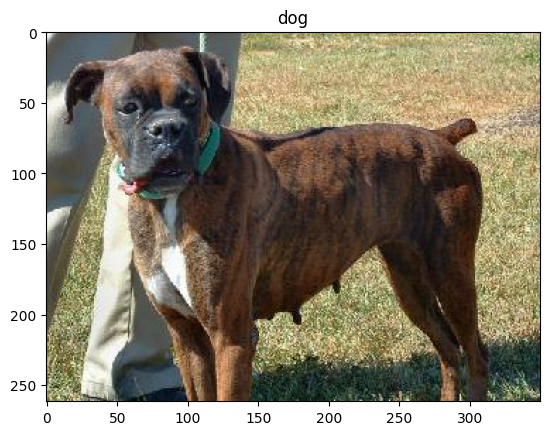

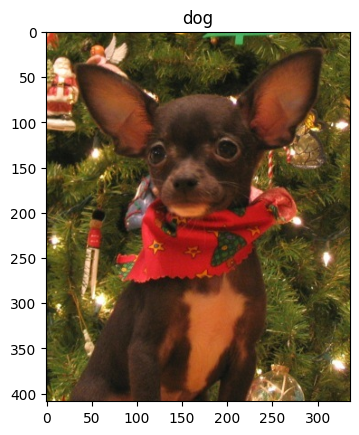

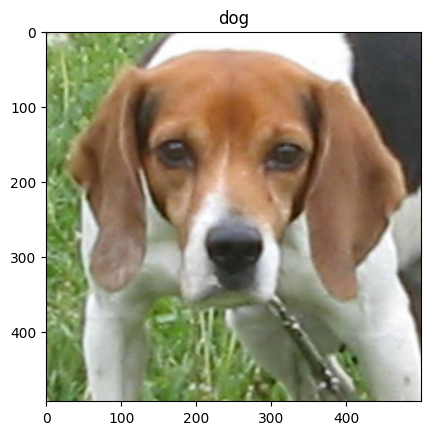

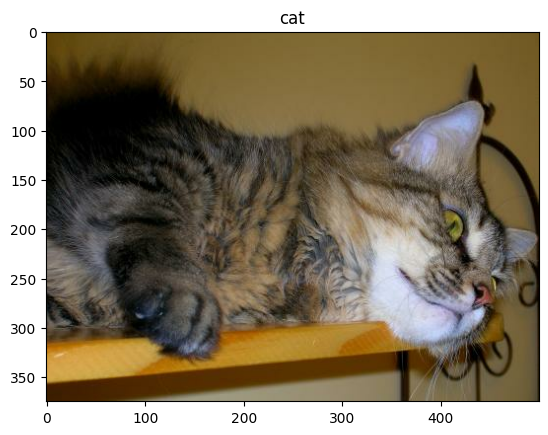

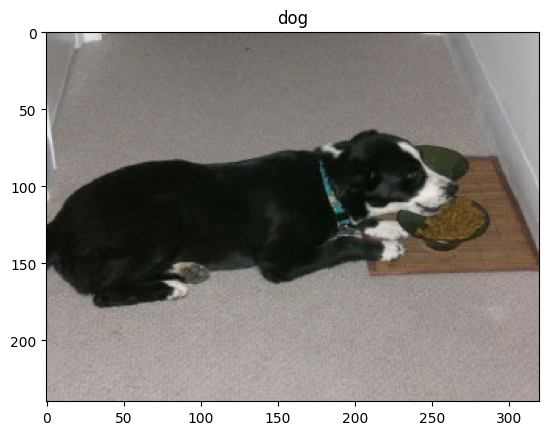

In [ ]:
import matplotlib.pyplot as plt
get_label_name = metadata.features['label'].int2str
get_label_name(0)  # 'cat'

for i in train.take(5):
    plt.figure()
    plt.imshow(i[0])
    plt.title(get_label_name(i[1]))

이미지 크기 맞추기
- crop, random crop
  - 객체를 crop하지 않는 경우
- resize, rescale
  - 왜곡
    - Numpy :PIL, OpenCV
    - Tensor: tf.keras, tf.image 
      - tensor를 그대로 가져다가 씀

In [ ]:
tf.image

<module 'tensorflow._api.v2.image' from 'c:\\MyCursorLab\\04_딥러닝_CNN\\.venv\\lib\\site-packages\\tensorflow\\_api\\v2\\image\\__init__.py'>

In [ ]:
dir(tf.image) # 간단한거는 PIL없이 가능

['ResizeMethod',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_sys',
 'adjust_brightness',
 'adjust_contrast',
 'adjust_gamma',
 'adjust_hue',
 'adjust_jpeg_quality',
 'adjust_saturation',
 'central_crop',
 'combined_non_max_suppression',
 'convert_image_dtype',
 'crop_and_resize',
 'crop_to_bounding_box',
 'decode_and_crop_jpeg',
 'decode_bmp',
 'decode_gif',
 'decode_image',
 'decode_jpeg',
 'decode_png',
 'draw_bounding_boxes',
 'encode_jpeg',
 'encode_png',
 'extract_glimpse',
 'extract_jpeg_shape',
 'extract_patches',
 'flip_left_right',
 'flip_up_down',
 'generate_bounding_box_proposals',
 'grayscale_to_rgb',
 'hsv_to_rgb',
 'image_gradients',
 'is_jpeg',
 'non_max_suppression',
 'non_max_suppression_overlaps',
 'non_max_suppression_padded',
 'non_max_suppression_with_scores',
 'pad_to_bounding_box',
 'per_image_standardization',
 'psnr',
 'random_brightness',
 'random_contrast',
 'random_crop',
 

In [ ]:
# 편하지만 기능이 많아서 우아하지 못함.
tf.keras.preprocessing.image
tf.keras.experimental   #편한기능이 있음
tf.keras.layers.experimental.preprocessing #레이어에서 resize,rescale

tf.image.resize

<function tensorflow.python.ops.image_ops_impl.resize_images_v2(images, size, method='bilinear', preserve_aspect_ratio=False, antialias=False, name=None)>

In [ ]:
for i in train.take(1):
    tf.image.resize(i[0],(200,2002)) #이미지 1개 200,200으로 바꿈

- map 
  - 함수형 패러다임으로 한 번에 동시에 여러개 적용하는 technique
  - `map(map_func, num_parallel_calls=None, deterministic=None)`

In [ ]:
def format(image,label):
    return image,label  # 그대로 출력

train.map(format)

<MapDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


- `x/255` :0~1사이의 값
  - 항상 양수 범위이기 때문에 잘못하면 zig zag현상으로 수렴이 잘 안됨  
#### zero centered
- `x /127.5 -1`: -1~+1사이의 값

In [ ]:
# 데이터타입 변경, scaling, resizing 함수 적용 
def format(image,label):
    image = tf.cast(image,tf.float32)
    # image = image/255.        # 0 ~ 1 범위(양수범위)
    image = (image/127.5) - 1   # -1 ~ 1 범위(zero-centered)
    image = tf.image.resize(image,[160,160])
    return image,label 

In [ ]:
train.map(format)

<MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

Pretraned 모델 사용방법
- tf.hub  
사전에 학습된 모델을 다운로드하고 사용할 수 있다  
https://www.tensorflow.org/hub?hl=ko

- keras 네 탑재된 모델 사용
  - `tf.keras.applications`
    - VGG16, ResNet50, InceptionV3, MobileNetV2, DenseNet 등  
    > 보통 VGG, ResNet(상징적) 많이 사용 
    - 간단한 구조로 customizing 용이
  - 성능 정확도, 메모리, trainable parameters , **효율성** 비교해야함 
    - 정확도 : ResNet50, ResNet101, SENet
    - 효율성 : MobileNet, ShffuleNet
      - real-time, running on mobile
> 오캄의 면도날 

ShuffleNet : 2017년에 등장한 경량화된 컨볼루션 신경망 모델 ,모바일 기기나 임베디드 시스템에 사용가능  
https://sotudy.tistory.com/16


- ILSVRC 2010: SuperVision (에러율 28.2%)  
- ILSVRC 2011: SuperVision (에러율 25.8%)  
- ILSVRC 2012: AlexNet (에러율 15.3%)  
- ILSVRC 2013: ZFNet (에러율 11.2%)  
- ILSVRC 2014: GoogLeNet (에러율 6.7%)  
- ILSVRC 2015: ResNet (에러율 3.6%)  
- ILSVRC 2016: Ensemble of Multiple Models (에러율 2.99%)  
https://tensorflow.blog/2016/09/27/imagenet-ilsvrc-2016-results-out/  
- ILSVRC 2017: SENet (에러율 2.25%)  
https://deep-learning-study.tistory.com/539  
- ILSVRC 2018: SENet (에러율 2.13%)  
- ILSVRC 2019: EfficientNet (에러율1.5%) https://greeksharifa.github.io/computer%20vision/2022/03/01/EfficientNet/

In [ ]:
m1 = tf.keras.applications.MobileNet()
m2 = tf.keras.applications.MobileNetV2()

17225924/17225924 [==============================] - 2s 0us/step


In [ ]:
m1.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

In [ ]:
m2.summary()  # Connected to : ResNet영향 받음

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

Depthwise: 
- 1x1 convolution : 차원 축소용 (GoogLeNet)
- 깊이 조절 AlexNet GPU 두개로 분리 (group convolution의 일종의 하나로 depth관점에서  convolution( dialate convolution에서 정리할 예정)
  - Conv + BN + ReLU 
  - ResNet영향 받음

depth 마다 특징을 더하지 않고 그대로 유지시킴
- parameter수가 급격히 줄어듦
 
 -`include_top`: 예측하는 Fully connected layer 가져올지 말지 정함(fine tunning or feature extractor)
- 복잡한 모델은 다양한 데이터 학습시 일반화된 성능을 갖을거라는 가정 

In [ ]:
m3 = tf.keras.applications.VGG16()
m3.summary() # 1억3천800만개의 파라미터

553467096/553467096 [==============================] - 51s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                           

- MobileNetV2 : connected to 
- feature extractor모듈에서 global avg pooling

In [ ]:
m2 = tf.keras.applications.MobileNetV2(include_top=True) 
m2.summary()# FCNN: Global Average Pooling 으로 분류기 (GoogLeNet)

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [ ]:
m3= tf.keras.applications.MobileNetV2(include_top=False) # 파라미터 차이가 큼 : 2,257,984 (3,538,984 - 1281000(Dense))
m3.summary() 

9406464/9406464 [==============================] - 1s 0us/step
Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 Conv1 (Conv2D)                 (None, None, None,   864         ['input_5[0][0]']                
                                32)                                                               
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, None, None,   128         ['Conv1[0][0]']                  
                

### MobileNet V2
Google은 2018년 MobileNet V2를 제안한 논문인 MobileNetV2: Inverted Residuals and Linear Bottlenecks를 발표했습니다.

MobileNet V2는 이전 모델인 MobileNet을 개선한 네트워크 입니다. 따라서 MobileNet과 동일하게 MobileNet V2는 임베디드 디바이스 또는 모바일 장치를 타겟으로 하는 단순한 구조의 경량화 네트워크를 설계하는데 초점이 맞춰져 있습니다.  
https://velog.io/@woojinn8/LightWeight-Deep-Learning-7.-MobileNet-v2

In [ ]:
# MobileNetV2
# https://deep-learning-study.tistory.com/532
# 학습 레이어가 28 layers
# 이론과 다른 이유 : BN, activation function도 레이어로 봄
len(m2.layers),len(m3.layers)

(156, 23)

In [ ]:
m3.trainable = False  # 모델 전체 학습 안 시킴 Trainable prams :0
# m3.summary()

In [ ]:
# global_avg_pooling = tf.keras.layers.GlobalAvgPool2D()

# last = tf.keras.layers.Dense(1) # activation 함수 없이 구현

# model = tf.keras.models.Sequential([   
#     # Input    ---> 오류!!
#     m3, global_avg_pooling, last
# ])

# model.summary()   

전략
- input shape 맞추기
- tf.data batchdataset: batch 크기만큼 바꿔야함

In [ ]:
train.map(format), train.map(format).batch(32) # batch처리후 차원이 변경됨

(<MapDataset element_spec=(TensorSpec(shape=(160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <BatchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [ ]:
# 최종 모델 구현
# 1. pre-trained 모델(MobileNetV2)을 불러와서 데이터 입력 크기 맞춤 
m3 = tf.keras.applications.MobileNetV2(include_top=False,input_shape=(224,224,3))

# 2. 모델 구성
global_avg_pooling = tf.keras.layers.GlobalAvgPool2D()
last = tf.keras.layers.Dense(1) # activation 함수 없이 구현

model = tf.keras.models.Sequential([
    m3, global_avg_pooling, last
])

m3.trainable = False

# 전처리 : rescaling, resizing함수 
def format(image,label):
    image = tf.cast(image,tf.float32)
    image = (image/127.5) - 1   # -1 ~ 1 범위(zero-centered)
    image = tf.image.resize(image,[224,224])
    return image,label 

train = train.map(format)

# 4. batch 지정 : ((NOne,224,224,3),(None))
train_batch = train.batch(32)

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
# test용 하나 만들어서 확인
# batch 사이즈 크기 맞춤
for image,label in train_batch.take(1):  # train_batch 에서 배치 1개 가져오기,mage 와 label 분리
    pass
m3(image)  # (32, 7, 7, 1280) , 학습이 아닌 feature extractor라서  image 만 모델에 입력

<tf.Tensor: shape=(32, 7, 7, 1280), dtype=float32, numpy=
array([[[[0.        , 0.        , 0.        , ..., 1.564973  ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 6.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 2.9052901 ,
          0.        , 0.        ],
         ...,
         [0.        , 0.6939166 , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.46476787, 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.55846226, 0.        , ..., 0.        ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 4.629633  ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 6.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 5.117239  ,
          0.        , 0.        ],
         ...,
         [0.        , 0.      

In [ ]:
# 5.  compile binary classification :개,고양이
model.compile(optimizer='adam',
              # from_logits 마지막레이어에 activation function 넣지 않을때 씀
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# 6. train  : accuracy: 0.9923
model.fit(train_batch,epochs=5)  # X_train,y_train
# RTX 3060 약 3분 소요

Epoch 1/5
582/582 [==============================] - 36s 58ms/step - loss: 0.0641 - accuracy: 0.9773
Epoch 2/5
582/582 [==============================] - 33s 56ms/step - loss: 0.0317 - accuracy: 0.9895
Epoch 3/5
582/582 [==============================] - 33s 57ms/step - loss: 0.0270 - accuracy: 0.9909
Epoch 4/5
582/582 [==============================] - 34s 59ms/step - loss: 0.0240 - accuracy: 0.9919
Epoch 5/5
582/582 [==============================] - 35s 60ms/step - loss: 0.0217 - accuracy: 0.9925
